In [1]:
import os
#os.environ['SPS_HOME'] = '/Users/annalena/Documents/GitHub/fsps'
os.environ['SPS_HOME'] = '/home/annalena_data/sps_fsps'

# Load supported SSP templates

This notebook shows how to load and use the supported SSP templates. Currently we have support for custom build SSP templates stored in hdf5 format for which we provide a template based on Bruzual&Charlot2003 models. Additionally we support all SSP templates that the pyPipe3D project uses. Those templates come in astronomy friendly fits file format.

In [2]:
# NBVAL_SKIP
from rubix.spectra.ssp.templates import BruzualCharlot2003

BruzualCharlot2003

2026-02-27 14:54:38,555 - rubix - INFO - 
   ___  __  _____  _____  __
  / _ \/ / / / _ )/  _/ |/_/
 / , _/ /_/ / _  |/ /_>  <
/_/|_|\____/____/___/_/|_|


2026-02-27 14:54:38,557 - rubix - INFO - Rubix version: 0.0.post486+g0c7c23dcd.d20260226
2026-02-27 14:54:38,557 - rubix - INFO - JAX version: 0.7.2
2026-02-27 14:54:38,557 - rubix - INFO - Running on [CpuDevice(id=0)] devices
2026-02-27 14:54:38,558 - rubix - WARNING - python-fsps is not installed. Please install it to use this function. Install using pip install fsps and check the installation page: https://dfm.io/python-fsps/current/installation/ for more details. Especially, make sure to set all necessary environment variables.


HDF5SSPGrid(age=Array([0.00000000e+00, 1.25892999e-04, 1.41254000e-04, 1.58488998e-04,
       1.77827998e-04, 1.99526999e-04, 2.23872994e-04, 2.51188991e-04,
       2.81838991e-04, 3.16228980e-04, 3.54814983e-04, 3.98108998e-04,
       4.46685997e-04, 5.01189963e-04, 5.62343979e-04, 6.30960974e-04,
       7.07949977e-04, 7.94333988e-04, 8.91256961e-04, 9.99999931e-04,
       1.04712998e-03, 1.09647994e-03, 1.14814995e-03, 1.20225991e-03,
       1.25892996e-03, 1.31825998e-03, 1.38038001e-03, 1.44543999e-03,
       1.51355995e-03, 1.58488995e-03, 1.65958994e-03, 1.73779996e-03,
       1.81970000e-03, 1.90545991e-03, 1.99525990e-03, 2.08928995e-03,
       2.18775985e-03, 2.29086983e-03, 2.39882991e-03, 2.51187989e-03,
       2.63026985e-03, 2.75422982e-03, 2.88402988e-03, 3.01994989e-03,
       3.16226995e-03, 3.31130996e-03, 3.46735981e-03, 3.63077992e-03,
       3.80188995e-03, 3.98106966e-03, 4.16868972e-03, 4.36514989e-03,
       4.57087997e-03, 4.78628976e-03, 5.01185982e-03, 5.2480

In [3]:
print(BruzualCharlot2003.flux.shape)

(6, 221, 842)


In [4]:
# NBVAL_SKIP
print(BruzualCharlot2003.age)

[0.00000000e+00 1.25892999e-04 1.41254000e-04 1.58488998e-04
 1.77827998e-04 1.99526999e-04 2.23872994e-04 2.51188991e-04
 2.81838991e-04 3.16228980e-04 3.54814983e-04 3.98108998e-04
 4.46685997e-04 5.01189963e-04 5.62343979e-04 6.30960974e-04
 7.07949977e-04 7.94333988e-04 8.91256961e-04 9.99999931e-04
 1.04712998e-03 1.09647994e-03 1.14814995e-03 1.20225991e-03
 1.25892996e-03 1.31825998e-03 1.38038001e-03 1.44543999e-03
 1.51355995e-03 1.58488995e-03 1.65958994e-03 1.73779996e-03
 1.81970000e-03 1.90545991e-03 1.99525990e-03 2.08928995e-03
 2.18775985e-03 2.29086983e-03 2.39882991e-03 2.51187989e-03
 2.63026985e-03 2.75422982e-03 2.88402988e-03 3.01994989e-03
 3.16226995e-03 3.31130996e-03 3.46735981e-03 3.63077992e-03
 3.80188995e-03 3.98106966e-03 4.16868972e-03 4.36514989e-03
 4.57087997e-03 4.78628976e-03 5.01185982e-03 5.24806976e-03
 5.49539970e-03 5.75438980e-03 6.02559000e-03 6.30956003e-03
 6.60691969e-03 6.91829994e-03 7.24434992e-03 7.58575974e-03
 7.94326980e-03 8.317619

# Load SSP template via custom config

This shows how to use a custom configuration to load an SSP template that is stored under some file location on your disk.

In [5]:
# NBVAL_SKIP
config_emiles = {
        "name": "EMILES",
        "format": "HDF5",
        "source": "https://github.com/kateharborne/SimSpin/tree/main/data/",
        "file_name": "EMILES.h5",
        "fields": {
            "age": {
                "name": "age",
                "units": "yr",
                "in_log": False
            },
            "metallicity": {
                "name": "metallicity",
                "units": "",
                "in_log": False
            },
            "wavelength": {
                "name": "wavelength",
                "units": "Angstrom",
                "in_log": False
            },
            "flux": {
                "name": "flux",
                "units": "Lsun/Angstrom",
                "in_log": False
            }
        }
    }

In [10]:
# NBVAL_SKIP
from rubix.spectra.ssp.grid import HDF5SSPGrid
ssp_emiles = HDF5SSPGrid.from_file(config_emiles, file_location="../rubix/spectra/ssp/templates")
ssp_emiles

HDF5SSPGrid(age=Array([ 0.03      ,  0.04      ,  0.05      ,  0.06      ,  0.07      ,
        0.08      ,  0.09      ,  0.09999999,  0.14999999,  0.19999999,
        0.25      ,  0.29999998,  0.35      ,  0.39999998,  0.45      ,
        0.5       ,  0.59999996,  0.7       ,  0.79999995,  0.9       ,
        1.        ,  1.25      ,  1.5       ,  1.75      ,  2.        ,
        2.2499998 ,  2.5       ,  2.75      ,  3.        ,  3.2499998 ,
        3.5       ,  3.75      ,  4.        ,  4.4999995 ,  5.        ,
        5.5       ,  6.        ,  6.4999995 ,  7.        ,  7.5       ,
        8.        ,  8.499999  ,  8.999999  ,  9.5       , 10.        ,
       10.499999  , 11.        , 11.5       , 12.        , 12.499999  ,
       12.999999  , 13.5       , 14.        ], dtype=float32), metallicity=Array([0.0001, 0.0003, 0.0006, 0.001 , 0.002 , 0.004 , 0.008 , 0.01  ,
       0.0198, 0.024 , 0.03  , 0.04  ], dtype=float32), wavelength=Array([ 1680.2,  1681.1,  1682. , ..., 19997.9, 199

In [11]:
# NBVAL_SKIP
ssp_emiles.age.shape

(53,)

In [12]:
ssp_emiles.age

Array([ 0.03      ,  0.04      ,  0.05      ,  0.06      ,  0.07      ,
        0.08      ,  0.09      ,  0.09999999,  0.14999999,  0.19999999,
        0.25      ,  0.29999998,  0.35      ,  0.39999998,  0.45      ,
        0.5       ,  0.59999996,  0.7       ,  0.79999995,  0.9       ,
        1.        ,  1.25      ,  1.5       ,  1.75      ,  2.        ,
        2.2499998 ,  2.5       ,  2.75      ,  3.        ,  3.2499998 ,
        3.5       ,  3.75      ,  4.        ,  4.4999995 ,  5.        ,
        5.5       ,  6.        ,  6.4999995 ,  7.        ,  7.5       ,
        8.        ,  8.499999  ,  8.999999  ,  9.5       , 10.        ,
       10.499999  , 11.        , 11.5       , 12.        , 12.499999  ,
       12.999999  , 13.5       , 14.        ], dtype=float32)

In [13]:
# NBVAL_SKIP
ssp_emiles.metallicity.shape

(12,)

In [ ]:
import numpy

ssp_emiles.metallicity/0.012

Array([0.00833333, 0.025     , 0.05      , 0.08333334, 0.16666667,
       0.33333334, 0.6666667 , 0.8333333 , 1.65      , 2.        ,
       2.5       , 3.3333333 ], dtype=float32)

In [9]:
# NBVAL_SKIP
ssp.wavelength.shape

(20356,)

In [ ]:
# NBVAL_SKIP
ssp.flux.shape

(6, 221, 6521)

# Let's plot some example spectra

In [ ]:
# NBVAL_SKIP
import matplotlib.pyplot as plt
import numpy as np

Text(0, 0.5, 'Flux [Lsun/Angstrom]')

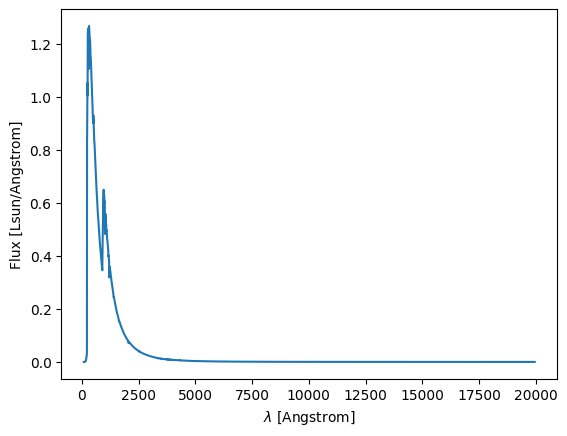

In [ ]:
# NBVAL_SKIP
plt.plot(ssp.wavelength,ssp.flux[0][0])
plt.xlabel(r'$\lambda$ [%s]'%config["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config["fields"]["flux"]["units"])
#plt.yscale("log")

Text(0, 0.5, 'Flux [Lsun/Angstrom]')

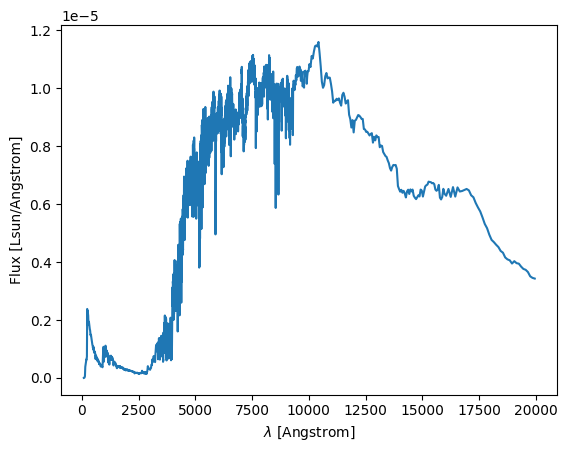

In [ ]:
# NBVAL_SKIP
plt.plot(ssp.wavelength,ssp.flux[-1][-1])
plt.xlabel(r'$\lambda$ [%s]'%config["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config["fields"]["flux"]["units"])
#plt.yscale("log")

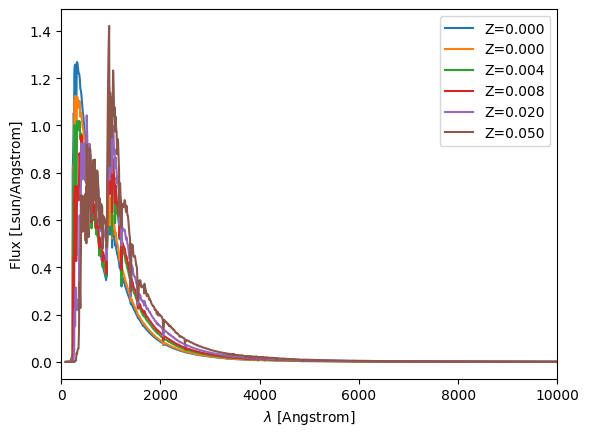

In [ ]:
# NBVAL_SKIP
for i in range(len(ssp.metallicity)):
    plt.plot(ssp.wavelength,ssp.flux[i][0], label=r'Z=%0.3f'%ssp.metallicity[i])
plt.xlabel(r'$\lambda$ [%s]'%config["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config["fields"]["flux"]["units"])
#plt.yscale("log")
plt.xlim(0,10000)
plt.legend()

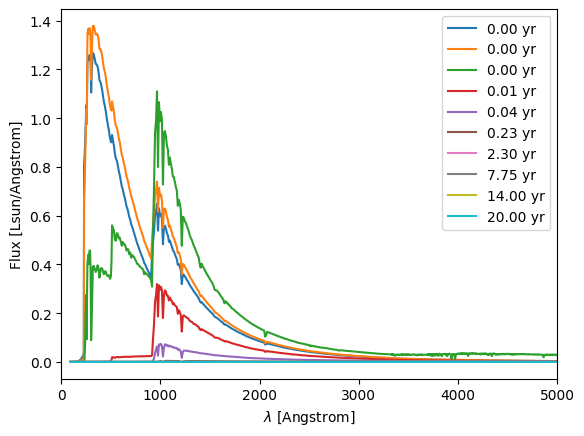

In [ ]:
# NBVAL_SKIP
ages = np.linspace(0,len(ssp.age),10)
for age in ages:
    plt.plot(ssp.wavelength,ssp.flux[0][int(age)], label='%.2f %s'%(ssp.age[int(age)], config["fields"]["age"]["units"]))
plt.xlabel(r'$\lambda$ [%s]'%config["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config["fields"]["flux"]["units"])
#plt.yscale("log")
plt.xlim(0,5000)
plt.legend()

# Automatic download supported SSP template
Rubix supports automatic download of a supported SSP template from a specified url in case the template can't be found on disk under the file_location specified.

In [ ]:
# NBVAL_SKIP
config = {
        "name": "Mastar Charlot & Bruzual (2019)",
        "format": "pyPipe3D",
        "source": "https://ifs.astroscu.unam.mx/pyPipe3D/templates/",
        "file_name": "MaStar_CB19.slog_1_5.fits.gz",
        "fields": {
            "age": {
                "name": "age",
                "units": "Gyr",
                "in_log": False
            },
            "metallicity": {
                "name": "metallicity",
                "units": "",
                "in_log": False
            },
            "wavelength": {
                "name": "wavelength",
                "units": "Angstrom",
                "in_log": False
            },
            "flux": {
                "name": "flux",
                "units": "Lsun/Angstrom",
                "in_log": False
            }
        }
    }

In [ ]:
# NBVAL_SKIP
from rubix.spectra.ssp.grid import pyPipe3DSSPGrid
ssp = pyPipe3DSSPGrid.from_file(config, file_location="../rubix/spectra/ssp/templates")
ssp

TypeCheckError: Type-check error whilst checking the parameters of rubix.spectra.ssp.grid.SSPGrid.convert_units.
The problem arose whilst typechecking parameter 'data'.
Actual value: f32[39](numpy)
Expected type: typing.Union[Float[Array, '...'], Int[Array, '...']].
----------------------
Called with parameters: {'data': f32[39](numpy), 'from_units': 'Gyr', 'to_units': 'Gyr'}
Parameter annotations: (data: Union[Float[Array, '...'], Int[Array, '...']], from_units: str, to_units: str) -> Any.


In [ ]:
# NBVAL_SKIP
ssp.age.shape

(53,)

In [ ]:
# NBVAL_SKIP
ssp.metallicity.shape

(12,)

In [ ]:
# NBVAL_SKIP
ssp.wavelength.shape

(20356,)

In [ ]:
# NBVAL_SKIP
ssp.flux.shape

# Lets plot some example spectra
Example for Mastar templates

In [ ]:
# NBVAL_SKIP
import matplotlib.pyplot as plt
import numpy as np

Text(0, 0.5, 'Flux [Lsun/Angstrom]')

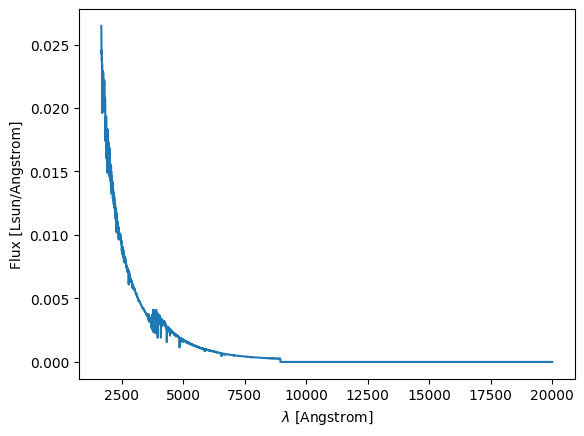

In [ ]:
# NBVAL_SKIP
plt.plot(ssp.wavelength,ssp.flux[0][0])
plt.xlabel(r'$\lambda$ [%s]'%config["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config["fields"]["flux"]["units"])
#plt.yscale("log")

Text(0, 0.5, 'Flux [Lsun/Angstrom]')

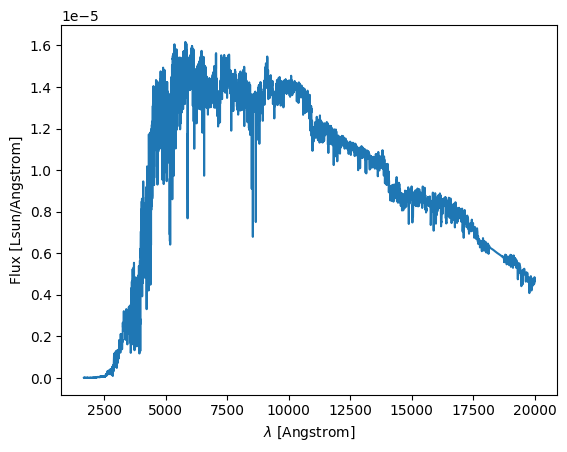

In [ ]:
# NBVAL_SKIP
plt.plot(ssp.wavelength,ssp.flux[-1][-1])
plt.xlabel(r'$\lambda$ [%s]'%config["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config["fields"]["flux"]["units"])
#plt.yscale("log")

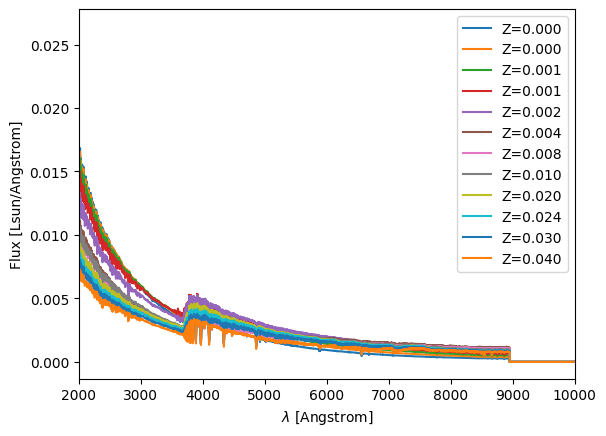

In [ ]:
# NBVAL_SKIP
for i in range(len(ssp.metallicity)):
    plt.plot(ssp.wavelength,ssp.flux[i][0], label=r'Z=%0.3f'%ssp.metallicity[i])
plt.xlabel(r'$\lambda$ [%s]'%config["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config["fields"]["flux"]["units"])
#plt.yscale("log")
plt.xlim(2000,10000)
plt.legend()

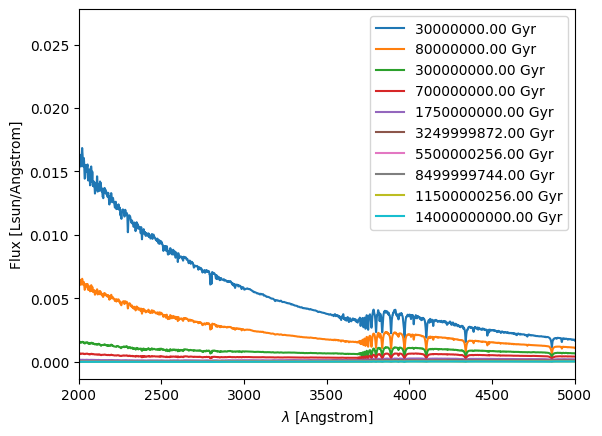

In [ ]:
# NBVAL_SKIP
ages = np.linspace(0,len(ssp.age),10)
for age in ages:
    plt.plot(ssp.wavelength,ssp.flux[0][int(age)], label='%.2f %s'%(ssp.age[int(age)], config["fields"]["age"]["units"]))
plt.xlabel(r'$\lambda$ [%s]'%config["fields"]["wavelength"]["units"])
plt.ylabel(r'Flux [%s]'%config["fields"]["flux"]["units"])
#plt.yscale("log")
plt.xlim(2000,5000)
plt.legend()